# CNN for Handwritten Digit Classification
Based on the example from Deep Learning with Python, Chapter 5.1
Enhanced with best practices for reproducibility and evaluation

## 1. Import Libraries

In [1]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Keras imports
from keras import layers, models
from keras.datasets import mnist
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import RMSprop
import tensorflow as tf

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Set Random Seeds for Reproducibility

In [2]:
def set_seeds(seed=42):
    """Set random seeds for reproducibility"""
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    # Ensure reproducibility for GPU operations
    os.environ['PYTHONHASHSEED'] = str(seed)

# Set seeds
set_seeds(42)
print("Random seeds set for reproducibility")

Random seeds set for reproducibility


## 3. Define CNN Model Architecture

In [3]:
def build_cnn_model():
    """Build the CNN model architecture as specified in the example"""
    model = models.Sequential()

    # Add Input layer as recommended by Keras to avoid warning
    model.add(layers.Input(shape=(28, 28, 1)))

    # Conv2D + MaxPooling layers with Batch Normalization
    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())

    # Flatten and Dense layers for classification
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))

    return model

print("Model architecture defined")

Model architecture defined


## 4. Load and Preprocess Data

In [4]:
def prepare_data():
    """Load and preprocess the MNIST dataset"""
    # Load data
    (train_images, train_labels), (test_images, test_labels) = mnist.load_data()

    # Reshape to add channel dimension
    train_images = train_images.reshape((60000, 28, 28, 1))
    test_images = test_images.reshape((10000, 28, 28, 1))

    # Normalize pixel values to [0, 1]
    train_images = train_images.astype('float32') / 255
    test_images = test_images.astype('float32') / 255

    # Convert labels to categorical (one-hot encoding)
    train_labels = to_categorical(train_labels)
    test_labels = to_categorical(test_labels)

    return (train_images, train_labels), (test_images, test_labels)

# Load data
print("Loading and preprocessing MNIST dataset...")
(train_images, train_labels), (test_images, test_labels) = prepare_data()
print(f"Training samples: {len(train_images)}")
print(f"Test samples: {len(test_images)}")

Loading and preprocessing MNIST dataset...
Training samples: 60000
Test samples: 10000


## 5. Build and Display Model

In [5]:
# Build model
print("Building enhanced CNN model with batch normalization and dropout...")
model = build_cnn_model()
model.summary()

Building enhanced CNN model with batch normalization and dropout...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,962 (367.04 KB)

 Trainable params: 93,642 (365.79 KB)

 Non-trainable params: 320 (1.25 KB)

## 6. Compile Model

In [6]:
# Compile model with optimized settings
print("Compiling model with RMSprop optimizer...")
optimizer = RMSprop(learning_rate=0.001)
model.compile(optimizer=optimizer,
             loss='categorical_crossentropy',
             metrics=['accuracy'])
print("Model compiled successfully!")

Compiling model with RMSprop optimizer...
Model compiled successfully!


## 7. Setup Callbacks

In [7]:
# Get output directory (current directory for notebook)
output_dir = os.getcwd()

# Setup callbacks
print("Setting up callbacks (EarlyStopping, ModelCheckpoint, LR Reduction)...")
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(output_dir, 'best_model.keras'),
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=0.00001,
        verbose=1
    )
]
print("Callbacks configured")

Setting up callbacks (EarlyStopping, ModelCheckpoint, LR Reduction)...
Callbacks configured


## 8. Train Model

**Note:** Set to 3 epochs for testing. Change to `epochs=10` for full training.

In [8]:
# Train model with validation split
print("Training model with validation split and callbacks...")
print("Note: Using 3 epochs for testing. Change to epochs=10 for full training")

history = model.fit(train_images, train_labels,
                   epochs=3,  # Reduced for testing - change to 10 for full training
                   batch_size=128,
                   validation_split=0.2,
                   callbacks=callbacks,
                   verbose=1)

print("Training completed!")

Training model with validation split and callbacks...
Note: Using 3 epochs for testing. Change to epochs=10 for full training
Epoch 1/3
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8014 - loss: 0.6370
Epoch 1: val_accuracy improved from None to 0.10858, saving model to /Users/spasco/Projects/Harvard/CSCI-E-89b-NLP/assignments/3/part3/best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9006 - loss: 0.3261 - val_accuracy: 0.1086 - val_loss: 6.2152 - learning_rate: 0.0010
Epoch 2/3
374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9646 - loss: 0.1234
Epoch 2: val_accuracy improved from 0.10858 to 0.97825, saving model to /Users/spasco/Projects/Harvard/CSCI-E-89b-NLP/assignments/3/part3/best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9670 - loss: 0.1148 - val_accuracy: 0.9783 - val_loss: 0.0818 - learning_rate: 0.0010
Epoch 3/3
371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9749 - loss: 0.0868
Epoch 3: val_accuracy imp

## 9. Evaluate Model on Test Set

In [9]:
# Evaluate on test set
print("\nEvaluating on test set...")
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


Evaluating on test set...
Test Loss: 0.0346
Test Accuracy: 0.9895 (98.95%)


## 10. Plot Training History


Plotting training and validation metrics...
Plot saved to /Users/spasco/Projects/Harvard/CSCI-E-89b-NLP/assignments/3/part3/part3_training_history.png


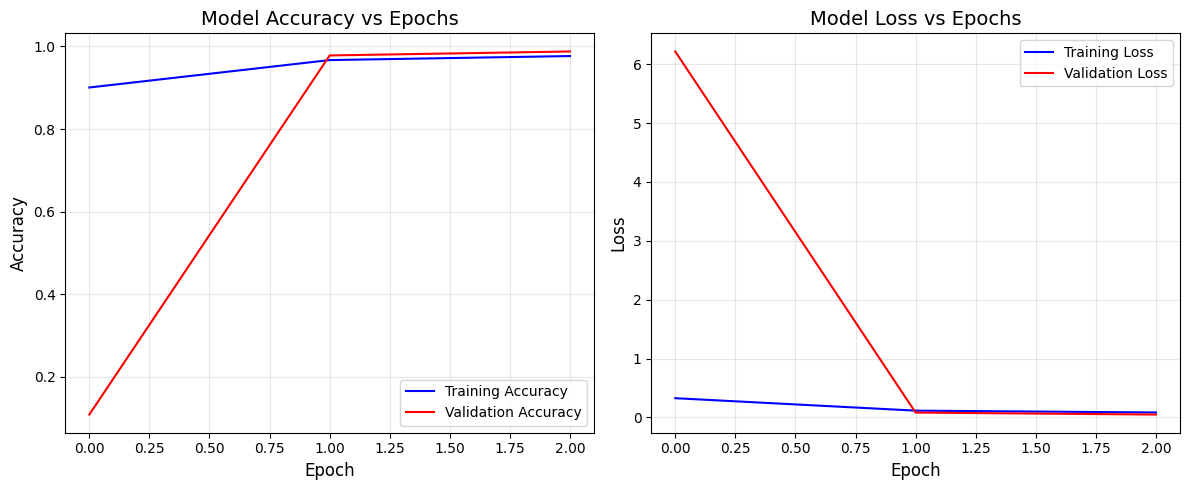

In [10]:
def plot_training_history(history, output_dir):
    """Plot training and validation accuracy versus epochs"""
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], 'b-', label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy')
    plt.title('Model Accuracy vs Epochs', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], 'b-', label='Training Loss')
    plt.plot(history.history['val_loss'], 'r-', label='Validation Loss')
    plt.title('Model Loss vs Epochs', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    # Save plot
    output_path = os.path.join(output_dir, 'part3_training_history.png')
    plt.savefig(output_path, dpi=100, bbox_inches='tight')
    print(f"Plot saved to {output_path}")
    plt.show()

# Plot training history
print("\nPlotting training and validation metrics...")
plot_training_history(history, output_dir)

## 11. Generate Confusion Matrix


Generating confusion matrix...
Confusion matrix saved to /Users/spasco/Projects/Harvard/CSCI-E-89b-NLP/assignments/3/part3/part3_confusion_matrix.png


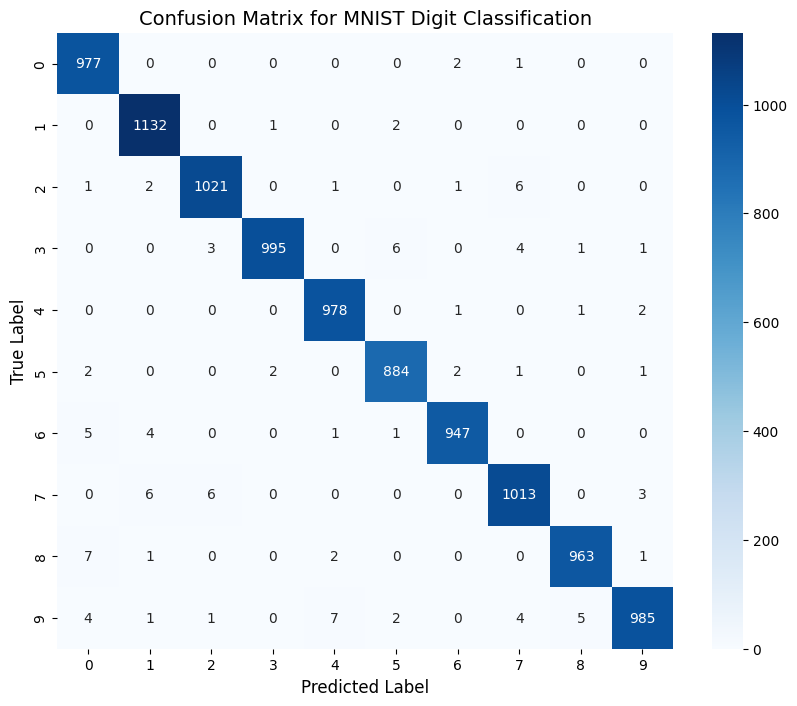

In [11]:
def plot_confusion_matrix(model, test_images, test_labels, output_dir):
    """Generate and plot confusion matrix"""
    # Get predictions
    predictions = model.predict(test_images, verbose=0)
    pred_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(test_labels, axis=1)

    # Generate confusion matrix
    cm = confusion_matrix(true_classes, pred_classes)

    # Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True)
    plt.title('Confusion Matrix for MNIST Digit Classification', fontsize=14)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)

    # Save plot
    output_path = os.path.join(output_dir, 'part3_confusion_matrix.png')
    plt.savefig(output_path, dpi=100, bbox_inches='tight')
    print(f"Confusion matrix saved to {output_path}")
    plt.show()

# Generate confusion matrix
print("\nGenerating confusion matrix...")
plot_confusion_matrix(model, test_images, test_labels, output_dir)

## 12. Detailed Classification Report

In [15]:
def evaluate_model_detailed(model, test_images, test_labels):
    """Generate detailed classification report"""
    predictions = model.predict(test_images, verbose=0)
    pred_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(test_labels, axis=1)

    print("\n" + "=" * 50)
    print("DETAILED CLASSIFICATION REPORT")
    print("=" * 50)
    print(classification_report(true_classes, pred_classes,
                              target_names=[str(i) for i in range(10)]))

    # Calculate per-class accuracy
    print("\nPer-Class Accuracy:")
    for i in range(10):
        mask = true_classes == i
        class_acc = np.mean(pred_classes[mask] == i)
        print(f"  Digit {i}: {class_acc:.4f} ({class_acc*100:.2f}%)")

# Generate detailed evaluation
print("\nGenerating detailed classification report...")
evaluate_model_detailed(model, test_images, test_labels)


Generating detailed classification report...

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


Per-Class Accuracy:
  Digit 0: 0.9969 (99.69%)
  Digit 1: 0.9974 (99.74%)
  Digit 2: 0.9893 (98.93%)
  Digit 3: 0.9851 (98.51%)
  Digit 4: 0.9959 (99.59%)
  Digit

## 13. Save Final Model

In [13]:
# Save final model
print("\nSaving final model...")
final_model_path = os.path.join(output_dir, 'part3_cnn_model.keras')
model.save(final_model_path)
print(f"Model saved to {final_model_path}")


Saving final model...
Model saved to /Users/spasco/Projects/Harvard/CSCI-E-89b-NLP/assignments/3/part3/part3_cnn_model.keras


## 14. Final Summary

In [14]:
# Print final summary
print("\n" + "=" * 50)
print("TRAINING COMPLETE!")
print("=" * 50)
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Total epochs trained: {len(history.history['accuracy'])}")


TRAINING COMPLETE!
Final Training Accuracy: 0.9768
Final Validation Accuracy: 0.9878
Test Accuracy: 0.9895
Total epochs trained: 3
